Preparing multimodal networks for: Chicago, Illinois, USA
  Loading cached drive graphs from disk...
  Loading cached bike graphs from disk...
  Loading cached walk graphs from disk...
Nodes: drive=29,360, bike=111,109, walk=299,456
Common nodes across all three networks: 21,220

Building a pool of 120,000 random OD pairs for stratified sampling by distance band…

Candidate OD pairs by distance band (before stratified sampling):
  short (<2 km): 2,734 candidates
  medium (2–8 km): 27,169 candidates
  long (>8 km): 90,097 candidates

Total stratified OD pairs used in analysis: 6,000 (short (<2 km): 2,000, medium (2–8 km): 2,000, long (>8 km): 2,000)

Computing multimodal shortest paths and circuity…
  … processed 500 of 6,000 OD pairs
  … processed 1,000 of 6,000 OD pairs
  … processed 1,500 of 6,000 OD pairs
  … processed 2,000 of 6,000 OD pairs
  … processed 2,500 of 6,000 OD pairs
  … processed 3,000 of 6,000 OD pairs
  … processed 3,500 of 6,000 OD pairs
  … processed 4,000 of 6,000

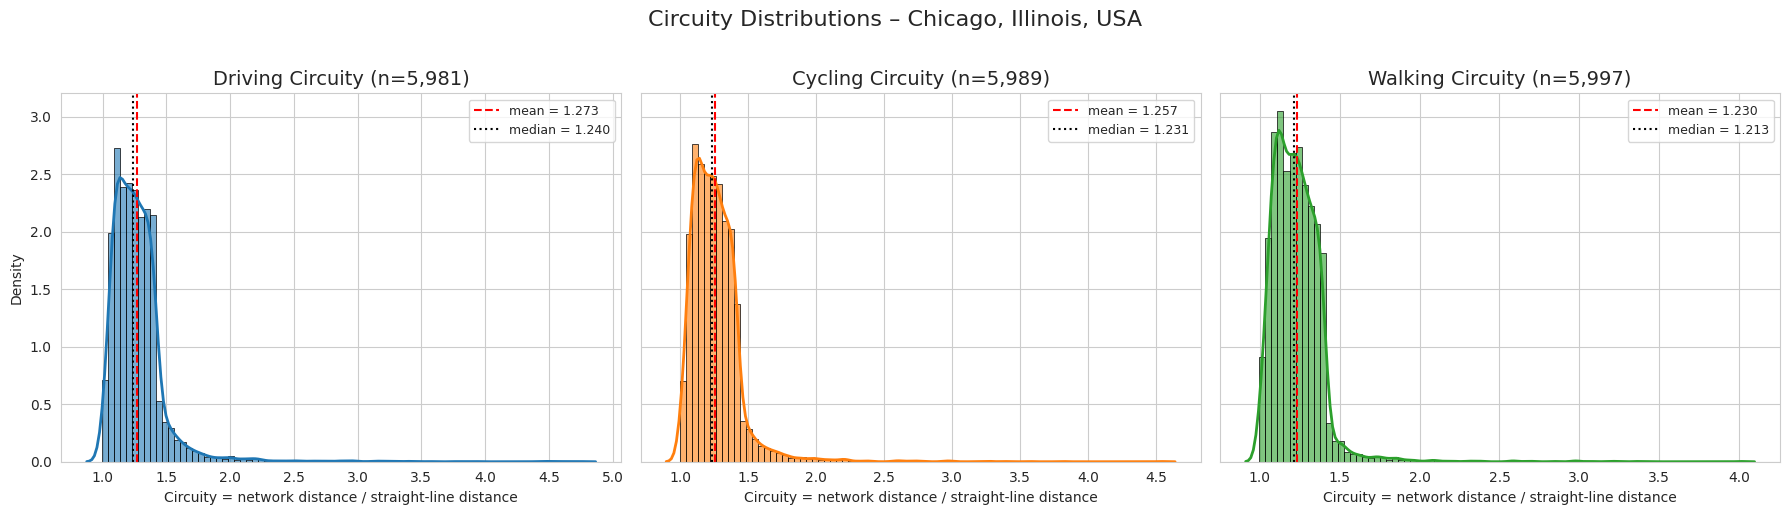

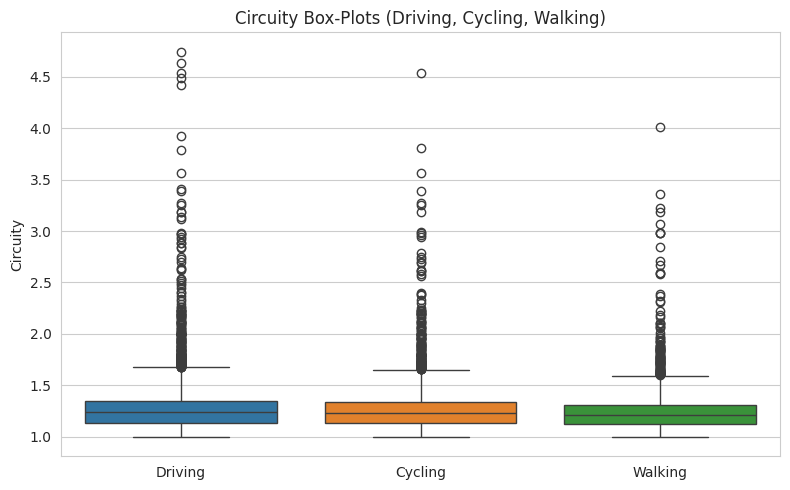


=== Circuity by distance band and mode (stratified sample) ===

Band: short (<2 km)
  Driving: mean=1.376, median=1.338, n=1,992
  Cycling: mean=1.345, median=1.324, n=1,993
  Walking: mean=1.294, median=1.284, n=1,997

Band: medium (2–8 km)
  Driving: mean=1.266, median=1.252, n=1,996
  Cycling: mean=1.254, median=1.243, n=1,997
  Walking: mean=1.232, median=1.227, n=2,000

Band: long (>8 km)
  Driving: mean=1.176, median=1.151, n=1,993
  Cycling: mean=1.171, median=1.148, n=1,999
  Walking: mean=1.163, median=1.144, n=2,000


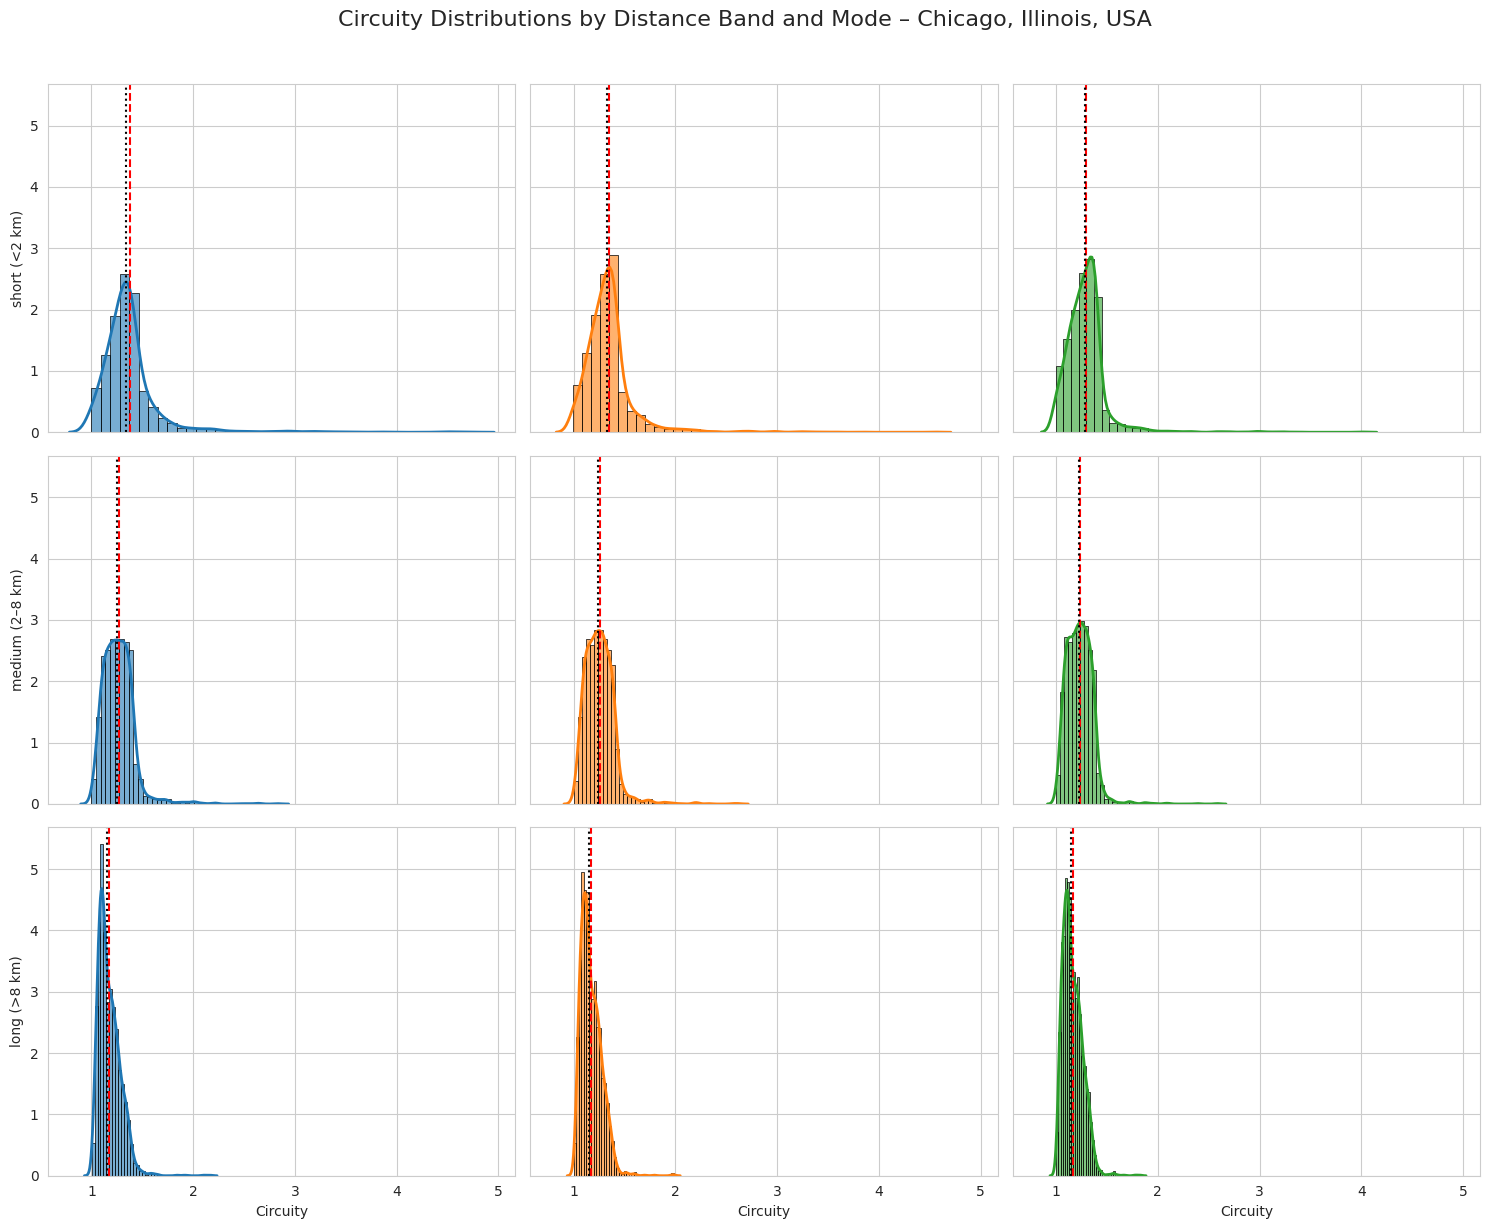


Interpretation guide:
  • Stratified sampling ensures each distance band is well
    populated, so comparisons across bands and modes are not
    dominated by long trips.
  • If mean/median circuity stays in a narrow range across bands,
    the network offers consistently direct routes for both local
    and longer trips, for all modes.

Visualizing a sample OD pair with valid routes for all modes (band: medium (2–8 km), origin=261235222, dest=266720617)


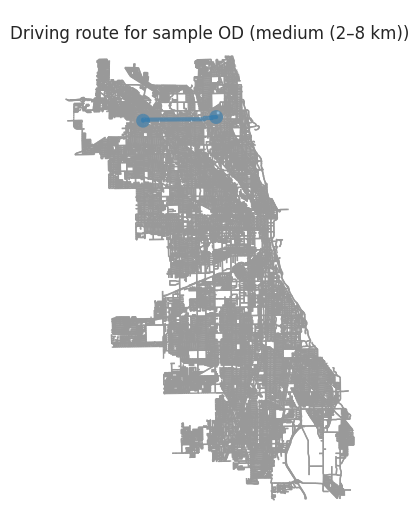

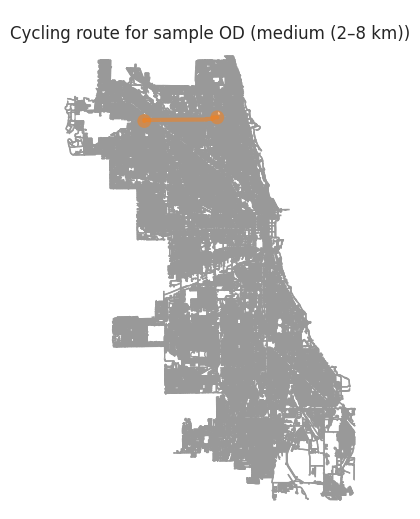

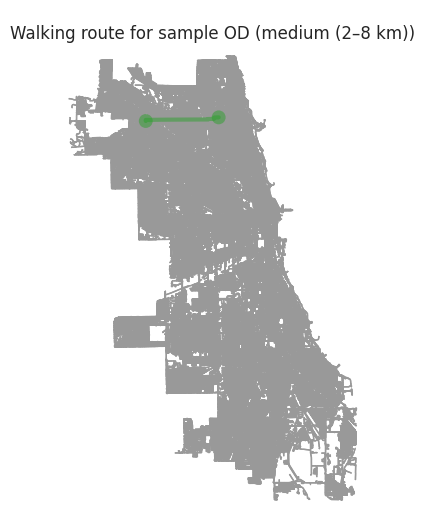

In [ ]:
# ==============================================================
# Multimodal Circuity in Chicago
# Evaluating network efficiency for driving, cycling, and walking
#
# Reproducible workflow for:
# Kabir, S. M. R. (2025). Multimodal Circuity in Chicago:
# Evaluating Urban Transport Network Efficiency Using Open Data.
#
# Revisions:
#   (1) OD sampling is explicitly isotropic: we uniformly sample
#       nodes across the network, approximating geometric coverage
#       of the whole city (cf. Costa et al., 2025, Cities 166, 106087).
#   (2) A single shared OD set is used for all three modes
#       (driving, cycling, walking) to ensure strict comparability.
#   (3) Distance-based trip categories with literature-informed
#       thresholds (short, medium, long) and stratified sampling.
#   (4) Sample OD pair visualization for all three modes.
#   (5) Checks if multimodal networks are already saved
#       locally as GraphML and skips downloading if so.
#   (6) Save all figures (plots) to disk as PNGs.
#
# ==============================================================

# 1. Install packages
# !pip install -q osmnx geopy matplotlib seaborn

# 2. Imports
import os
import random
import statistics
from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
import seaborn as sns
from geopy.distance import geodesic

sns.set_style("whitegrid")
# %matplotlib inline   # uncomment in notebooks if desired

# For reproducibility of OD sampling
random.seed(42)

# Use OSMnx internal cache as an extra speedup
ox.settings.use_cache = True
ox.settings.cache_folder = "./osm_cache"

# Directory to save figures
fig_dir = "./outputs/figures"
os.makedirs(fig_dir, exist_ok=True)

# --------------------------------------------------------------
# 3. Build/load multimodal street networks for Chicago (with cache)
# --------------------------------------------------------------
place_name = "Chicago, Illinois, USA"
print(f"Preparing multimodal networks for: {place_name}")

# Directory to store/load GraphML files
data_dir = "./data/chicago_graphs"
os.makedirs(data_dir, exist_ok=True)

# Simple slug for filenames
city_slug = (
    place_name.lower()
    .replace(",", "")
    .replace(" ", "_")
)

def load_or_build_graphs(place_name, mode, data_dir, city_slug):
    """
    Load unprojected and projected graphs for a given mode if they
    already exist on disk. Otherwise, download from OSM, then save.

    Returns
    -------
    G_unproj : networkx.MultiDiGraph
        Lat/lon graph (for geodesic distances).
    G_proj : networkx.MultiDiGraph
        Projected graph in a metric CRS (for path lengths).
    """
    mode_slug = mode.lower()
    unproj_fp = os.path.join(
        data_dir, f"{city_slug}_{mode_slug}_unproj.graphml"
    )
    proj_fp = os.path.join(
        data_dir, f"{city_slug}_{mode_slug}_proj.graphml"
    )

    # Case 1: both unprojected and projected graphs already exist
    if os.path.exists(unproj_fp) and os.path.exists(proj_fp):
        print(f"  Loading cached {mode} graphs from disk...")
        G_unproj = ox.load_graphml(unproj_fp)
        G_proj   = ox.load_graphml(proj_fp)
        return G_unproj, G_proj

    # Case 2: only unprojected exists → load, project, save projected
    if os.path.exists(unproj_fp) and not os.path.exists(proj_fp):
        print(f"  Loading cached {mode} unprojected graph and projecting...")
        G_unproj = ox.load_graphml(unproj_fp)
        G_proj   = ox.project_graph(G_unproj)
        ox.save_graphml(G_proj, proj_fp)
        return G_unproj, G_proj

    # Case 3: nothing exists → download from OSM, project, save both
    print(f"  Downloading {mode} graph from OSM…")
    G_unproj = ox.graph_from_place(place_name, network_type=mode_slug)
    ox.save_graphml(G_unproj, unproj_fp)

    print(f"  Projecting {mode} graph to metric CRS…")
    G_proj = ox.project_graph(G_unproj)
    ox.save_graphml(G_proj, proj_fp)

    return G_unproj, G_proj

# Build/load all three modes
G_drive_unproj, G_drive = load_or_build_graphs(
    place_name, "drive", data_dir, city_slug
)
G_bike_unproj, G_bike = load_or_build_graphs(
    place_name, "bike", data_dir, city_slug
)
G_walk_unproj, G_walk = load_or_build_graphs(
    place_name, "walk", data_dir, city_slug
)

print(
    f"Nodes: drive={G_drive.number_of_nodes():,}, "
    f"bike={G_bike.number_of_nodes():,}, "
    f"walk={G_walk.number_of_nodes():,}"
)

# --------------------------------------------------------------
# 4. Common nodes + isotropic OD sampling
# --------------------------------------------------------------
common_nodes = list(
    set(G_drive.nodes) & set(G_bike.nodes) & set(G_walk.nodes)
)
print(f"Common nodes across all three networks: {len(common_nodes):,}")

# --------------------------------------------------------------
# 5. Build a large pool of random OD pairs + distance bands
# --------------------------------------------------------------
distance_bands = [
    (0,     2000,         "short (<2 km)"),
    (2000,  8000,         "medium (2–8 km)"),
    (8000,  float("inf"), "long (>8 km)"),
]
band_labels = [b[2] for b in distance_bands]

# Parameters for stratified sampling
POOL_SIZE = 120_000          # large initial pool of random OD pairs
TARGET_PER_BAND = 2000       # per-band sample size

print(
    f"\nBuilding a pool of {POOL_SIZE:,} random OD pairs "
    "for stratified sampling by distance band…"
)

band_candidates = {label: [] for label in band_labels}
pool_count = 0

while pool_count < POOL_SIZE:
    o, d = random.sample(common_nodes, 2)

    # Straight-line distance using unprojected coordinates
    o_pt = (G_drive_unproj.nodes[o]["y"], G_drive_unproj.nodes[o]["x"])
    d_pt = (G_drive_unproj.nodes[d]["y"], G_drive_unproj.nodes[d]["x"])
    dist_m = geodesic(o_pt, d_pt).meters
    if dist_m == 0:
        continue

    # Assign to a distance band
    band_label = None
    for lower, upper, label in distance_bands:
        if lower <= dist_m < upper:
            band_label = label
            break

    if band_label is None:
        continue

    band_candidates[band_label].append(
        {"origin": o, "dest": d, "dist_m": dist_m, "band": band_label}
    )
    pool_count += 1

# Report how many candidate trips we have in each band
print("\nCandidate OD pairs by distance band (before stratified sampling):")
for label in band_labels:
    print(f"  {label}: {len(band_candidates[label]):,} candidates")

# --------------------------------------------------------------
# 6. Stratified sample: balanced OD sets per band
# --------------------------------------------------------------
OD_records = []  # shared OD list for all modes with band + distance

for label in band_labels:
    candidates = band_candidates[label]
    if not candidates:
        print(f"WARNING: no candidates found for band '{label}'.")
        continue

    n_available = len(candidates)
    n_sample = min(TARGET_PER_BAND, n_available)

    if n_available < TARGET_PER_BAND:
        print(
            f"WARNING: band '{label}' only has {n_available} candidates; "
            f"using all of them instead of {TARGET_PER_BAND}."
        )

    sampled = random.sample(candidates, n_sample)
    OD_records.extend(sampled)

print(
    f"\nTotal stratified OD pairs used in analysis: {len(OD_records):,} "
    f"({', '.join([f'{label}: {min(TARGET_PER_BAND, len(band_candidates[label])):,}' for label in band_labels])})"
)

# --------------------------------------------------------------
# 7. Compute circuity for each mode for the stratified OD set
# --------------------------------------------------------------
all_circuity = {"Driving": [], "Cycling": [], "Walking": []}

# Trip-level records for later distance-band analysis
trip_records = []  # dict(mode, circ, dist_m, band, origin, dest)

print("\nComputing multimodal shortest paths and circuity…")
for i, rec in enumerate(OD_records, start=1):
    if i % 500 == 0:
        print(f"  … processed {i:,} of {len(OD_records):,} OD pairs")

    o = rec["origin"]
    d = rec["dest"]
    base_dist = rec["dist_m"]  # straight-line (geodesic) distance
    band_label = rec["band"]

    if base_dist == 0:
        continue

    for mode, G in zip(
        all_circuity.keys(), [G_drive, G_bike, G_walk]
    ):
        try:
            # Length in metres along the network
            path_len = nx.shortest_path_length(G, o, d, weight="length")
            circ = path_len / base_dist

            # KEY FIX:
            # Filter extreme artifacts: discard very large circuity values
            # (e.g., >5), which correspond to rare, highly detoured paths
            # that distort the x-axis but are not representative of typical
            # urban circuity.
            if circ > 5:
                continue

            all_circuity[mode].append(circ)
            trip_records.append(
                {
                    "mode": mode,
                    "circ": circ,
                    "dist_m": base_dist,
                    "band": band_label,
                    "origin": o,
                    "dest": d,
                }
            )
        except nx.NetworkXNoPath:
            # No feasible route for this mode (rare in Chicago); skip
            continue

print("\nFinal sample sizes by mode:")
for m, vals in all_circuity.items():
    print(f"  {m}: {len(vals):,} valid circuity values")

# --------------------------------------------------------------
# 8. Overall circuity distributions (per mode)
# --------------------------------------------------------------
fig_modes, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = {"Driving": "#1f77b4", "Cycling": "#ff7f0e", "Walking": "#2ca02c"}

for ax, (mode, data) in zip(axes, all_circuity.items()):
    if not data:
        ax.text(
            0.5, 0.5, "No data",
            ha="center", va="center", transform=ax.transAxes
        )
        ax.set_title(mode)
        continue

    sns.histplot(
        data, bins=80, stat="density", ax=ax,
        color=colors[mode], alpha=0.6, edgecolor="k", linewidth=0.5
    )
    sns.kdeplot(data, ax=ax, color=colors[mode], linewidth=2)

    mean   = statistics.mean(data)
    median = statistics.median(data)

    ax.axvline(
        mean, color="red", linestyle="--",
        label=f"mean = {mean:.3f}"
    )
    ax.axvline(
        median, color="black", linestyle=":",
        label=f"median = {median:.3f}"
    )

    ax.set_title(f"{mode} Circuity (n={len(data):,})", fontsize=14)
    ax.set_xlabel("Circuity = network distance / straight-line distance")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Density")
plt.suptitle(f"Circuity Distributions – {place_name}", fontsize=16, y=1.02)

fig_modes.tight_layout()
fig_modes.savefig(
    os.path.join(fig_dir, "circuity_distributions_modes.png"),
    dpi=300, bbox_inches="tight"
)

plt.show()

# --------------------------------------------------------------
# 9. Box-plot comparison across modes
# --------------------------------------------------------------
fig_box, ax_box = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=[all_circuity[m] for m in all_circuity],
    palette=list(colors.values())
)
ax_box.set_xticks(range(3))
ax_box.set_xticklabels(all_circuity.keys())
ax_box.set_ylabel("Circuity")
ax_box.set_title("Circuity Box-Plots (Driving, Cycling, Walking)")
fig_box.tight_layout()

fig_box.savefig(
    os.path.join(fig_dir, "circuity_boxplots_modes.png"),
    dpi=300, bbox_inches="tight"
)

plt.show()

# --------------------------------------------------------------
# 10. Distance-band analysis (trip categories)
# --------------------------------------------------------------
band_stats = {label: {m: [] for m in all_circuity.keys()}
              for label in band_labels}

for record in trip_records:
    band_label = record["band"]
    mode = record["mode"]
    circ = record["circ"]
    band_stats[band_label][mode].append(circ)

print("\n=== Circuity by distance band and mode (stratified sample) ===")
for label in band_labels:
    print(f"\nBand: {label}")
    for mode in all_circuity.keys():
        vals = band_stats[label][mode]
        if len(vals) == 0:
            print(f"  {mode}: no trips in this band")
            continue
        mean_c = statistics.mean(vals)
        med_c  = statistics.median(vals)
        print(
            f"  {mode}: mean={mean_c:.3f}, median={med_c:.3f}, n={len(vals):,}"
        )

# Optional: visualise circuity distributions by band × mode
fig_bands, axes_bands = plt.subplots(
    nrows=len(band_labels), ncols=3,
    figsize=(15, 4 * len(band_labels)),
    sharex=True, sharey=True
)

for row, label in enumerate(band_labels):
    for col, mode in enumerate(["Driving", "Cycling", "Walking"]):
        ax = axes_bands[row, col]
        vals = band_stats[label][mode]

        if not vals:
            ax.text(
                0.5, 0.5, "No data",
                ha="center", va="center", transform=ax.transAxes
            )
            if col == 0:
                ax.set_ylabel(label)
            ax.set_title(mode)
            continue

        sns.histplot(
            vals, bins=40, stat="density", ax=ax,
            color=colors[mode], alpha=0.6, edgecolor="k", linewidth=0.5
        )
        sns.kdeplot(vals, ax=ax, color=colors[mode], linewidth=2)

        mean_c = statistics.mean(vals)
        med_c  = statistics.median(vals)

        ax.axvline(mean_c, color="red", linestyle="--")
        ax.axvline(med_c, color="black", linestyle=":")

        if col == 0:
            ax.set_ylabel(label)
        if row == len(band_labels) - 1:
            ax.set_xlabel("Circuity")

fig_bands.suptitle(
    f"Circuity Distributions by Distance Band and Mode – {place_name}",
    fontsize=16, y=1.02
)
fig_bands.tight_layout()

fig_bands.savefig(
    os.path.join(fig_dir, "circuity_distributions_by_band_and_mode.png"),
    dpi=300, bbox_inches="tight"
)

plt.show()

print("\nInterpretation guide:")
print("  • Stratified sampling ensures each distance band is well")
print("    populated, so comparisons across bands and modes are not")
print("    dominated by long trips.")
print("  • If mean/median circuity stays in a narrow range across bands,")
print("    the network offers consistently direct routes for both local")
print("    and longer trips, for all modes.")

# --------------------------------------------------------------
# 11. Sample OD pair visualization (Reviewer 2)
# --------------------------------------------------------------
od_modes = defaultdict(set)
for rec in trip_records:
    key = (rec["origin"], rec["dest"], rec["band"])
    od_modes[key].add(rec["mode"])

# Prefer a medium-distance example (2–8 km), then short, then long
preferred_bands = ["medium (2–8 km)", "short (<2 km)", "long (>8 km)"]
sample_key = None

for band in preferred_bands:
    for key, modes in od_modes.items():
        o, d, band_label = key
        if band_label == band and len(modes) == 3:
            sample_key = key
            break
    if sample_key is not None:
        break

if sample_key is not None:
    o, d, band_label = sample_key
    print(
        f"\nVisualizing a sample OD pair with valid routes for all modes "
        f"(band: {band_label}, origin={o}, dest={d})"
    )

    sample_routes = {}
    for mode, G in [("Driving", G_drive), ("Cycling", G_bike), ("Walking", G_walk)]:
        try:
            route = nx.shortest_path(G, o, d, weight="length")
            sample_routes[mode] = route
        except nx.NetworkXNoPath:
            sample_routes[mode] = None

    for mode, G in [("Driving", G_drive), ("Cycling", G_bike), ("Walking", G_walk)]:
        route = sample_routes.get(mode)
        if route is None:
            print(f"  No {mode.lower()} route found for sample OD.")
            continue

        fig_route, ax = ox.plot_graph_route(
            G,
            route,
            route_color=colors[mode],
            route_linewidth=3,
            node_size=0,
            bgcolor="white",
            show=False,
            close=False,
            figsize=(6, 6),
        )
        ax.set_title(f"{mode} route for sample OD ({band_label})")

        fig_route.savefig(
            os.path.join(
                fig_dir,
                f"sample_OD_route_{mode.lower().replace(' ', '_')}.png"
            ),
            dpi=300, bbox_inches="tight"
        )

        plt.show()

else:
    print(
        "\nNo OD pair with valid routes for all three modes was found "
        "for visualization. Consider increasing POOL_SIZE or adjusting "
        "the distance bands if this persists."
    )
